# CAB420, Transformers
Dr Simon Denman (s.denman@qut.edu.au)

## Overview

This example revisits transformers and in particular their application to images. We're going to train and compare three models on CIFAR-100:
* A ResNet
* A regular Vision Transformer, albeit using a convolutional encoding
* A Swin Transformer, also using a convolutional encoding

There is a lot of code in this example, but very little of it is new. The vast majority of which is copied from:
* `03_DCNNs/CAB420_DCNNs_Example_3_ResNet.ipynb`
* `09_Transformers/CAB420_Transformers_Example_2_Visual_Transformer.ipynb`
* `09_Transformers/CAB420_Transformers_Additional_Example_2_Swin_Transformers.ipynb`

Where we've got new things, we'll point them out, but for the most part we'll just be comparing these methods here using code we've already seen. The way that I'm structuring this example, we'll define all the code to help build our networks up the top, and then at the bottom there will be a flurry of activity as we create, train and evalaute them all.

### WARNING

**This example will not be quick to run if you don't have a GPU. Even if you do have a GPU, be careful with some of the parameters around network size - you may make things run very, very slowly.**

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf

import keras
from keras import layers
from keras.layers import Dense, Conv2D, BatchNormalization, Activation, AveragePooling1D, AveragePooling2D, Input, Flatten
from keras import ops
from keras.regularizers import l2

import matplotlib.pyplot as plt
import numpy as np
from time import time

E0000 00:00:1738483713.053113   64553 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738483713.055716   64553 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## The Data

We'll use CIFAR 100 here, and split that the same way that we've done in our other transformer examples. We'll also define some stuff here for the model training. We'll train all models for quite a while (or until they converge).

Finally, I'll also create a simple augmentation network here to use will all of our networks.

In [2]:
num_classes = 100
input_shape = (32, 32, 3)

# training parameters
learning_rate = 1e-3
batch_size = 256
num_epochs = 100
weight_decay = 0.0001
label_smoothing = 0.1

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_val = x_train[45000:, :]
y_val = y_train[45000:]
x_train = x_train[0:45000, :]
y_train = y_train[0:45000]

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)

I0000 00:00:1738483716.319771   64553 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


## Network Building Code

As forecast above, we've got a bunch of code here to build our networks for us. We'll break this down by network type.

### ResNet Functions

First up, we have our ResNet code. This is all taken from `03_DCNNs/CAB420_DCNNs_Example_3_ResNet.ipynb`. I'm just grabbing the V1 network builder here, but feel free to try a V2 network in here as well.

In [3]:
def resnet_layer(inputs,
                 num_filters=16,
                 kernel_size=3,
                 strides=1,
                 activation='relu',
                 batch_normalization=True,
                 conv_first=True):
    """2D Convolution-Batch Normalization-Activation stack builder

    # Arguments
        inputs (tensor): input tensor from input image or previous layer
        num_filters (int): Conv2D number of filters
        kernel_size (int): Conv2D square kernel dimensions
        strides (int): Conv2D square stride dimensions
        activation (string): activation name
        batch_normalization (bool): whether to include batch normalization
        conv_first (bool): conv-bn-activation (True) or
            bn-activation-conv (False)

    # Returns
        x (tensor): tensor as input to the next layer
    """
    conv = Conv2D(num_filters,
                  kernel_size=kernel_size,
                  strides=strides,
                  padding='same',
                  kernel_initializer='he_normal',
                  kernel_regularizer=l2(1e-4))

    x = inputs
    if conv_first:
        x = conv(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
    else:
        if batch_normalization:
            x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
        x = conv(x)
    return x


def resnet_v1(inputs, filters, num_res_blocks, pool_size):
    """ResNet Version 1 Model builder [a]

    Stacks of 2 x (3 x 3) Conv2D-BN-ReLU
    Last ReLU is after the shortcut connection.
    At the beginning of each stage, the feature map size is halved (downsampled)
    by a convolutional layer with strides=2, while the number of filters is
    doubled. Within each stage, the layers have the same number filters and the
    same number of filters.

    # Arguments
        inputs (layer):         the input tensor
        filters ([int]):        number of filters in each stage, length of list determines number of stages
        num_res_blocks (int):   number of residual blocks per stage
        pool_size (int):        size of the average pooling at the end

    # Returns
        output after global average pooling and flatten, ready for output
    """
    x = resnet_layer(inputs=inputs,
                     num_filters=filters[0])

    # Instantiate the stack of residual units
    for stack, filters in enumerate(filters):
        for res_block in range(num_res_blocks):
            strides = 1
            if stack > 0 and res_block == 0:  # first layer but not first stack
                strides = 2  # downsample
            y = resnet_layer(inputs=x,
                             num_filters=filters,
                             strides=strides)
            y = resnet_layer(inputs=y,
                             num_filters=filters,
                             activation=None)
            if stack > 0 and res_block == 0:  # first layer but not first stack
                # linear projection residual shortcut connection to match
                # changed dims
                x = resnet_layer(inputs=x,
                                 num_filters=filters,
                                 kernel_size=1,
                                 strides=strides,
                                 activation=None,
                                 batch_normalization=False)
            x = keras.layers.add([x, y])
            x = Activation('relu')(x)
 
    # Add classifier on top.
    # v1 does not use BN after last shortcut connection-ReLU
    x = AveragePooling2D(pool_size=pool_size)(x)
    y = Flatten()(x)

    return y

### Vision Transformer Code

Next up we have the first of our transformers, with code taken from `09_Transformers/CAB420_Transformers_Example_2_Visual_Transformer.ipynb`. The code here is unchanged from what we had in that example, though note that we're using the convolutional encoder.

In [4]:
conv_channels = [64, 128]
positional_emb = True
dropout_rate = 0.1

transformer_units = [256, 128]
transformer_layers = 2
projection_dim = 128

num_heads = 4  # Attention heads

# small function to create a simple MLP
def mlp(x, hidden_units, dropout_rate):
    # create dense layers, with a drop-out in between
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class CCTTokenizer(layers.Layer):
    def __init__(
        self,
        kernel_size=3,
        pooling_kernel_size=2,
        conv_channels=[16, 32, 32],
        **kwargs,
    ):
        super().__init__(**kwargs)

        # This is our tokenizer.
        self.conv_model = keras.Sequential()
        for i in conv_channels:
            self.conv_model.add(layers.Conv2D(i, (kernel_size, kernel_size), padding='same'))
            self.conv_model.add(layers.MaxPooling2D(pooling_kernel_size, pooling_kernel_size))

    def call(self, images):
        outputs = self.conv_model(images)
        # After passing the images through our mini-network the spatial dimensions
        # are flattened to form sequences.
        reshaped = keras.ops.reshape(
            outputs,
            (
                -1,
                keras.ops.shape(outputs)[1] * keras.ops.shape(outputs)[2],
                keras.ops.shape(outputs)[-1],
            ),
        )
        return reshaped
    
class PositionEmbedding(keras.layers.Layer):
    def __init__(
        self,
        sequence_length,
        initializer="glorot_uniform",
        **kwargs,
    ):
        super().__init__(**kwargs)
        if sequence_length is None:
            raise ValueError("`sequence_length` must be an Integer, received `None`.")
        self.sequence_length = int(sequence_length)
        self.initializer = keras.initializers.get(initializer)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "sequence_length": self.sequence_length,
                "initializer": keras.initializers.serialize(self.initializer),
            }
        )
        return config

    def build(self, input_shape):
        feature_size = input_shape[-1]
        self.position_embeddings = self.add_weight(
            name="embeddings",
            shape=[self.sequence_length, feature_size],
            initializer=self.initializer,
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs, start_index=0):
        shape = keras.ops.shape(inputs)
        feature_length = shape[-1]
        sequence_length = shape[-2]
        # trim to match the length of the input sequence, which might be less
        # than the sequence_length of the layer.
        position_embeddings = keras.ops.convert_to_tensor(self.position_embeddings)
        position_embeddings = keras.ops.slice(
            position_embeddings,
            (start_index, 0),
            (sequence_length, feature_length),
        )
        return keras.ops.broadcast_to(position_embeddings, shape)

    def compute_output_shape(self, input_shape):
        return input_shape    

def create_vit_classifier():
    inputs = layers.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    
    cct_tokenizer = CCTTokenizer(conv_channels = conv_channels)
    encoded_patches = cct_tokenizer(augmented)

    sequence_length = encoded_patches.shape[1]
    encoded_patches += PositionEmbedding(sequence_length=sequence_length)(encoded_patches)
        
    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate)(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=dropout_rate)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Dropout(0.5)(representation)
    
    # Add the MLP
    features = layers.GlobalAveragePooling1D()(representation)
    # Classify outputs.
    logits = layers.Dense(num_classes, activation='softmax')(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model


### Swin Transformer Code

Finally, we have our Swin Transformer. The code below is all taken from `09_Transformers/CAB420_Transformers_Additional_Example_2_Swin_Transformers.ipynb`, but here I'm going to deviate a little bit from what we've done in that example. In particular, I will:
* Use a convolutional encoder before I break things out into patches
* Start with $4 \times 4$ patches in my transformer (rather than $2 \times 2$) so that I can have a couple of convolutional layers in my patch encoder.
* Not do patch merging after the last group of transfofmers, instead I'll just pool those tokens.

Here, I'll use many of the same settings in terms of encoder size, number of transformer layers, etc, that we have in the vision transformer above.

In [5]:
# Convert embedded patches to query, key, and values with a learnable additive value
qkv_bias = True
window_size = 2  # Size of attention window
shift_size = 1  # Size of shifting window

# compute number of patches
patch_size = (4, 4)  # 2-by-2 sized patches
num_patch_x = input_shape[0] // patch_size[0]
num_patch_y = input_shape[1] // patch_size[1]

def window_partition(x, window_size):
    _, height, width, channels = x.shape
    patch_num_y = height // window_size
    patch_num_x = width // window_size
    x = ops.reshape(x, (-1, patch_num_y, window_size, patch_num_x, window_size, channels))
    x = ops.transpose(x, (0, 1, 3, 2, 4, 5))
    windows = ops.reshape(x, (-1, window_size, window_size, channels))
    return windows

def window_reverse(windows, window_size, height, width, channels):
    patch_num_y = height // window_size
    patch_num_x = width // window_size
    x = ops.reshape(windows, ( -1, patch_num_y, patch_num_x, window_size, window_size, channels))
    x = ops.transpose(x, (0, 1, 3, 2, 4, 5))
    x = ops.reshape(x, (-1, height, width, channels))
    return x
    
class WindowAttention(layers.Layer):
    def __init__(
        self,
        dim,
        window_size,
        num_heads,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.dropout = layers.Dropout(dropout_rate)
        self.proj = layers.Dense(dim)

        num_window_elements = (2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1)
        self.relative_position_bias_table = self.add_weight(shape=(num_window_elements, self.num_heads),
                                                            initializer=keras.initializers.Zeros(), trainable=True)
        coords_h = np.arange(self.window_size[0])
        coords_w = np.arange(self.window_size[1])
        coords_matrix = np.meshgrid(coords_h, coords_w, indexing="ij")
        coords = np.stack(coords_matrix)
        coords_flatten = coords.reshape(2, -1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.transpose([1, 2, 0])
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)

        self.relative_position_index = keras.Variable(initializer=relative_position_index, shape=relative_position_index.shape, 
                                                      dtype="int", trainable=False)

    def call(self, x, mask=None):
        _, size, channels = x.shape
        head_dim = channels // self.num_heads
        x_qkv = self.qkv(x)
        x_qkv = ops.reshape(x_qkv, (-1, size, 3, self.num_heads, head_dim))
        x_qkv = ops.transpose(x_qkv, (2, 0, 3, 1, 4))
        q, k, v = x_qkv[0], x_qkv[1], x_qkv[2]
        q = q * self.scale
        k = ops.transpose(k, (0, 1, 3, 2))
        attn = q @ k

        num_window_elements = self.window_size[0] * self.window_size[1]
        relative_position_index_flat = ops.reshape(self.relative_position_index, (-1,))
        relative_position_bias = ops.take(self.relative_position_bias_table, relative_position_index_flat, axis=0)
        relative_position_bias = ops.reshape(relative_position_bias, (num_window_elements, num_window_elements, -1))
        relative_position_bias = ops.transpose(relative_position_bias, (2, 0, 1))
        attn = attn + ops.expand_dims(relative_position_bias, axis=0)

        if mask is not None:
            nW = mask.shape[0]
            mask_float = ops.cast(ops.expand_dims(ops.expand_dims(mask, axis=1), axis=0), "float32")
            attn = ops.reshape(attn, (-1, nW, self.num_heads, size, size)) + mask_float
            attn = ops.reshape(attn, (-1, self.num_heads, size, size))
            attn = keras.activations.softmax(attn, axis=-1)
        else:
            attn = keras.activations.softmax(attn, axis=-1)
        attn = self.dropout(attn)

        x_qkv = attn @ v
        x_qkv = ops.transpose(x_qkv, (0, 2, 1, 3))
        x_qkv = ops.reshape(x_qkv, (-1, size, channels))
        x_qkv = self.proj(x_qkv)
        x_qkv = self.dropout(x_qkv)
        return x_qkv

class SwinTransformer(layers.Layer):
    def __init__(
        self,
        dim,
        num_patch,
        num_heads,
        window_size=7,
        shift_size=0,
        num_mlp=1024,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.dim = dim  # number of input dimensions
        self.num_patch = num_patch  # number of embedded patches
        self.num_heads = num_heads  # number of attention heads
        self.window_size = window_size  # size of window
        self.shift_size = shift_size  # size of window shift
        self.num_mlp = num_mlp  # number of MLP nodes

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(dim, window_size=(self.window_size, self.window_size), num_heads=num_heads,
            qkv_bias=qkv_bias, dropout_rate=dropout_rate)
        self.drop_path = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)

        self.mlp = keras.Sequential(
            [
                layers.Dense(num_mlp),
                layers.Activation(keras.activations.gelu),
                layers.Dropout(dropout_rate),
                layers.Dense(dim),
                layers.Dropout(dropout_rate),
            ]
        )

        if min(self.num_patch) < self.window_size:
            self.shift_size = 0
            self.window_size = min(self.num_patch)

    def build(self, input_shape):
        if self.shift_size == 0:
            self.attn_mask = None
        else:
            height, width = self.num_patch
            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            mask_array = np.zeros((1, height, width, 1))
            count = 0
            for h in h_slices:
                for w in w_slices:
                    mask_array[:, h, w, :] = count
                    count += 1
            mask_array = ops.convert_to_tensor(mask_array)

            # mask array to windows
            mask_windows = window_partition(mask_array, self.window_size)
            mask_windows = ops.reshape(mask_windows, [-1, self.window_size * self.window_size])
            attn_mask = ops.expand_dims(mask_windows, axis=1) - ops.expand_dims(mask_windows, axis=2)
            attn_mask = ops.where(attn_mask != 0, -100.0, attn_mask)
            attn_mask = ops.where(attn_mask == 0, 0.0, attn_mask)
            self.attn_mask = keras.Variable(initializer=attn_mask, shape=attn_mask.shape,
                                            dtype=attn_mask.dtype,trainable=False)

    def call(self, x, training=False):
        height, width = self.num_patch
        _, num_patches_before, channels = x.shape
        x_skip = x
        x = self.norm1(x)
        x = ops.reshape(x, (-1, height, width, channels))
        if self.shift_size > 0:
            shifted_x = ops.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])
        else:
            shifted_x = x

        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = ops.reshape(x_windows, (-1, self.window_size * self.window_size, channels))
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        attn_windows = ops.reshape(attn_windows, (-1, self.window_size, self.window_size, channels))
        shifted_x = window_reverse(attn_windows, self.window_size, height, width, channels)
        if self.shift_size > 0:
            x = ops.roll(shifted_x, shift=[self.shift_size, self.shift_size], axis=[1, 2])
        else:
            x = shifted_x

        x = ops.reshape(x, (-1, height * width, channels))
        x = self.drop_path(x, training=training)
        x = x_skip + x
        x_skip = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = self.drop_path(x)
        x = x_skip + x
        return x

class PatchMerging(keras.layers.Layer):
    def __init__(self, num_patch, embed_dim):
        super().__init__()
        self.num_patch = num_patch
        self.embed_dim = embed_dim
        self.linear_trans = layers.Dense(2 * embed_dim, use_bias=False)

    def call(self, x):
        height, width = self.num_patch
        _, _, C = x.shape
        x = ops.reshape(x, (-1, height, width, C))
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = ops.concatenate((x0, x1, x2, x3), axis=-1)
        x = ops.reshape(x, (-1, (height // 2) * (width // 2), 4 * C))
        return self.linear_trans(x)

def create_swin_classifier():
    inputs = layers.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    
    cct_tokenizer = CCTTokenizer(conv_channels = conv_channels)
    x = cct_tokenizer(augmented)

    sequence_length = x.shape[1]
    x += PositionEmbedding(sequence_length=sequence_length)(x)
        
    # Create multiple layers of the Transformer block.
    for i in range(transformer_layers):
        x = SwinTransformer(dim=projection_dim*(2**i), num_patch=(num_patch_x // (2**i), num_patch_y // (2**i)), num_heads=num_heads, 
                            window_size=window_size, shift_size=0, num_mlp=projection_dim*2*(2**i), qkv_bias=qkv_bias, dropout_rate=dropout_rate)(x)
        x = SwinTransformer(dim=projection_dim*(2**i), num_patch=(num_patch_x // (2**i), num_patch_y // (2**i)), num_heads=num_heads, 
                            window_size=window_size, shift_size=shift_size, num_mlp=projection_dim*2*(2**i), qkv_bias=qkv_bias,dropout_rate=dropout_rate)(x)

        # only do patch merging if we're not at the last group
        if (i < (transformer_layers -1)):
            x = PatchMerging((num_patch_x // (2**i), num_patch_y // (2**i)), embed_dim=projection_dim*(2**i))(x)


    features = layers.GlobalAveragePooling1D()(x)

    # Classify outputs.
    logits = layers.Dense(num_classes, activation='softmax')(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model        

### Train and Evaluate Functions

Finally, we've got a function to train a model, and evaluate the three. There's nothing fancy in these, though with training note that:
* We're using AdamW, and the same learning rate and weight decay for all
* We're using label smoothing in our loss function
* We've got an early stopping callback to stop training once we converge

In [6]:
def run_experiment(model):
    # using adam with weight decay, as per the original example
    optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)

    # we'll get the standard accuracy metric (witch is top-1 accuracy) and also the top-5 accuracy, i.e.
    # how often the correct result is in the top 5 returned classes
    model.compile(optimizer=optimizer, loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"),
                           keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy")], jit_compile=False)

    # early stopping callback
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # fit the model
    history = model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=num_epochs, validation_data = (x_val, y_val),
                        callbacks=[early_stopping], verbose=False)

    return history, model
    
def eval_models(histories, models, names):

    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(3, 2, 1)
    for h,n in zip(histories, names):
        plt.plot(h.history["accuracy"], label = n + ": Top-1 Accuracy (Training)")
        plt.xlabel('Epoch')
        plt.ylabel('% Accuracy')
        plt.legend()

    ax = fig.add_subplot(3, 2, 2)
    for h,n in zip(histories, names):
        plt.plot(h.history["val_accuracy"], label = n + ": Top-1 Accuracy (Validation)")
        plt.xlabel('Epoch')
        plt.ylabel('% Accuracy')
        plt.legend()

    ax = fig.add_subplot(3, 2, 3)
    for h,n in zip(histories, names):
        plt.plot(h.history["top-5-accuracy"], label = n + ": Top-5 Accuracy (Training)")
        plt.xlabel('Epoch')
        plt.ylabel('% Accuracy')
        plt.legend()

    ax = fig.add_subplot(3, 2, 4)
    for h,n in zip(histories, names):
        plt.plot(h.history["val_top-5-accuracy"], label = n + ": Top-5 Accuracy (Validation)")
        plt.xlabel('Epoch')
        plt.ylabel('% Accuracy')
        plt.legend()

    ax = fig.add_subplot(3, 2, 5)
    for m,n in zip(models, names):
    
        train_predictions = m.predict(x_train, verbose=False)
        train_samples = len(x_train)
        
        cmc_train = []
        cmc_test = []
        rank = []
        for i in range(1,101):
            cmc_train.append(100.0*np.sum(tf.math.in_top_k(tf.argmax(y_train, axis=1), train_predictions, i))/train_samples)
            rank.append(i)

        plt.plot(rank, cmc_train, label= n + ": Training Data (%1.2f%% R-1)" % (cmc_train[0]))
        plt.grid()
        plt.legend()
        plt.xlabel('Rank')
        plt.ylabel('% Accuracy')

    ax = fig.add_subplot(3, 2, 6)
    for m,n in zip(models, names):
    
        test_predictions = m.predict(x_test, verbose=False)
        test_samples = len(x_test)
        
        cmc_train = []
        cmc_test = []
        rank = []
        for i in range(1,101):
            cmc_test.append(100.0*np.sum(tf.math.in_top_k(tf.argmax(y_test, axis=1), test_predictions, i))/test_samples)
            rank.append(i)

        plt.plot(rank, cmc_test, label= n + ": Testing Data (%1.2f%% R-1)" % (cmc_test[0]))
        plt.grid()
        plt.legend()
        plt.xlabel('Rank')
        plt.ylabel('% Accuracy')

## Training Models

Let's build and train some models now. Here, I'll try to keep all networks roughly similar in size, noting that this difficult with the very different types of network that we have.

For all models, I'm going to time how long they train for.

### ResNet

First up, ResNet. We'll use two residual blocks, with 64 and 128 filters. This will give us a network with aobut 700,000 parameters.

In [7]:
inputs = Input(shape=(32, 32, 3, ), name='img')
augmented = data_augmentation(inputs)
x = resnet_v1(augmented, [64, 128], 2, 16)
output = Dense(100, activation='softmax')(x)
model_resnet = keras.Model(inputs=inputs, outputs=output, name='simple_resnet_v1')
model_resnet.summary()

Model: "simple_resnet_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)    │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ img[0][0]         │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ activation[0][0], │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 690,660 (2.63 MB)

 Trainable params: 688,996 (2.63 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [8]:
resnet_start = time()
history_resnet, model_resnet = run_experiment(model_resnet)
resnet_finish = time()
resnet_time = resnet_finish - resnet_start

I0000 00:00:1738483721.395705   64660 cuda_dnn.cc:529] Loaded cuDNN version 90300


## VIT

Next up is our vision classifier. Here, we're going to use two transformer blocks, after a convolution encoder with two layers, with 64 and 128 filters in it. This gives us 64 patches (which might be a bit ugly to train), but a similar 750,000 parameters to our ResNet. We'll call the fact that we have two transformer blocks here similar to our two residual blocks in the ResNet (though really these things are so different that calling it equivilent is kind-of weird).

In [9]:
model_vit = create_vit_classifier()
model_vit.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cct_tokenizer       │ (None, 64, 128)   │     75,648 │ data_augmentatio… │
│ (CCTTokenizer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 64, 128)   │      8,192 │ cct_tokenizer[0]… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 128)   │          0 │ cct_tokenizer[0]… │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 64, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 256)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 128)   │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64, 128)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 757,476 (2.89 MB)

 Trainable params: 757,476 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
vit_start = time()
history_vit, model_vit = run_experiment(model_vit)
vit_finish = time()
vit_time = vit_finish - vit_start

## Swin Transformer

Finally we have the Swin Transformer. Here, I'm trying to be consistent with what we've got above, so we have:
* A convolutional encoder, same as the VIT.
* Two groups Swin Trasformer layers doing our windowed attention. This gives us four transformer layers, but as windowed attention relies on the shifting to propogate information about the place, we need to have these in pairs. 

The resulting network is a fair bit larger, about 1.5 million parameters, with those all really coming in the MLPs that are created in the transformers and the patch merging layer. If I had a second patch merging layer I could get another half a million parameters in there too. If I drop the embedding dimension we could bring parameter numbers more in-line with the other networks, but I think it's fairer to use the same token size / number of convolutional filters as a measure of equivilence (that said, you could argue otherwise pretty well too).

In [11]:
model_swin = create_swin_classifier()
model_swin.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cct_tokenizer_1     │ (None, 64, 128)   │     75,648 │ data_augmentatio… │
│ (CCTTokenizer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding… │ (None, 64, 128)   │      8,192 │ cct_tokenizer_1[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 64, 128)   │          0 │ cct_tokenizer_1[… │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_transformer    │ (None, 64, 128)   │    132,532 │ add_9[0][0]       │
│ (SwinTransformer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_transformer_1  │ (None, 64, 128)   │    132,788 │ swin_transformer… │
│ (SwinTransformer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_merging       │ (None, 16, 256)   │    131,072 │ swin_transformer… │
│ (PatchMerging)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_transformer_2  │ (None, 16, 256)   │    527,156 │ patch_merging[0]… │
│ (SwinTransformer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_transformer_3  │ (None, 16, 256)   │    527,220 │ swin_transformer… │
│ (SwinTransformer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ swin_transformer… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 100)       │     25,700 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,560,308 (5.95 MB)

 Trainable params: 1,559,924 (5.95 MB)

 Non-trainable params: 384 (3.00 KB)

In [12]:
swin_start = time()
history_swin, model_swin = run_experiment(model_swin)
swin_finish = time()
swin_time = swin_finish - swin_start

## Evaluation

First up, let's look at our runtimes.

In [13]:
print('ResNet trained for %d epochs in %02d:%02d minutes (%1.2f seconds per epoch)' % (len(history_resnet.history['accuracy']), resnet_time//60, resnet_time%60, resnet_time/len(history_resnet.history['accuracy'])))
print('VIT trained for %d epochs in %02d:%02d minutes (%1.2f seconds per epoch)' % (len(history_vit.history['accuracy']), vit_time//60, vit_time%60, vit_time/len(history_vit.history['accuracy'])))
print('Swin Transformer trained for %d epochs in %02d:%02d minutes (%1.2f seconds per epoch)' % (len(history_swin.history['accuracy']), swin_time//60, swin_time%60, swin_time/len(history_swin.history['accuracy'])))

ResNet trained for 38 epochs in 17:53 minutes (28.26 seconds per epoch)
VIT trained for 34 epochs in 06:18 minutes (11.15 seconds per epoch)
Swin Transformer trained for 46 epochs in 16:27 minutes (21.47 seconds per epoch)


These, perhaps, are not what you were expecting. These VIT is actually fastest, even with 64 tokens. There are somethings to unpack here:
* The VIT does allow for lots of parallelisation, and the network itself is not too deep. By using a GPU (which I have when I've trained this) we can get those benefits. If I made the VIT deeper, had more tokens, or didn't have a GPU, these results would be a lot uglier.
* Swin is slower. But isn't the whole idea is for this to be efficient??? Here, we're seeing the impact of those larger MLPs, and the the fact that we have four transformer blocks. Each transformer block is way more efficient than the standard VIT, but we have a bunch of other stuff in there that cancels this gain out.
* The ResNet is slow. Here, perhaps the depth is the culprit. While this has a similar number of parameters to our VIT, it is far deeper (we have 9 convolution layers in there). As we need to process layers sequentially, the simple fact that we have to go through all those operations one after the other, even though none of them are any where near as big as our attention operations, slows us down. Probably in terms of "layers repsonsible for learning stuff", we've got far more of those in our ResNet than in either of the other networks.

One other interesting thing to consider is how many epochs these networks train for. The Swin Transformer manages to go for a lot longer before it stops due to overfitting. The other two tap out at about the same time. Having a transformer run for longer is not surprising. CNNs, by virtue of the nature of the grid structure of images and the gridded nature of the convolution operation, have a really strong inductive bias for capturing local spatial relationships in images. For image classification, this is good, and helps the network learn. For the transformer based methods, this inductive bias is not there, and the simply compare all patches to each other - so they have to learn those sorts of biases about nearby patches being relevent. This takes time, but the flip size is that they can also learn other useful non-local relationships which a CNN can't really get. The Swin Transformer kind-of sits half way between this, as it uses local windows, but still shifts these to propogate local information, and them merges patches as well. On the whole, the lack of this inductive bias an the power to learn other weird relationships means that the transformers will often take longer to converge.

One thing to note here is that different training runs will produced variations in the above. On average when I've run this, I've seen the ResNet finish first, followed by the VIT, and then the Swin Transformer, but it does vary every run through.

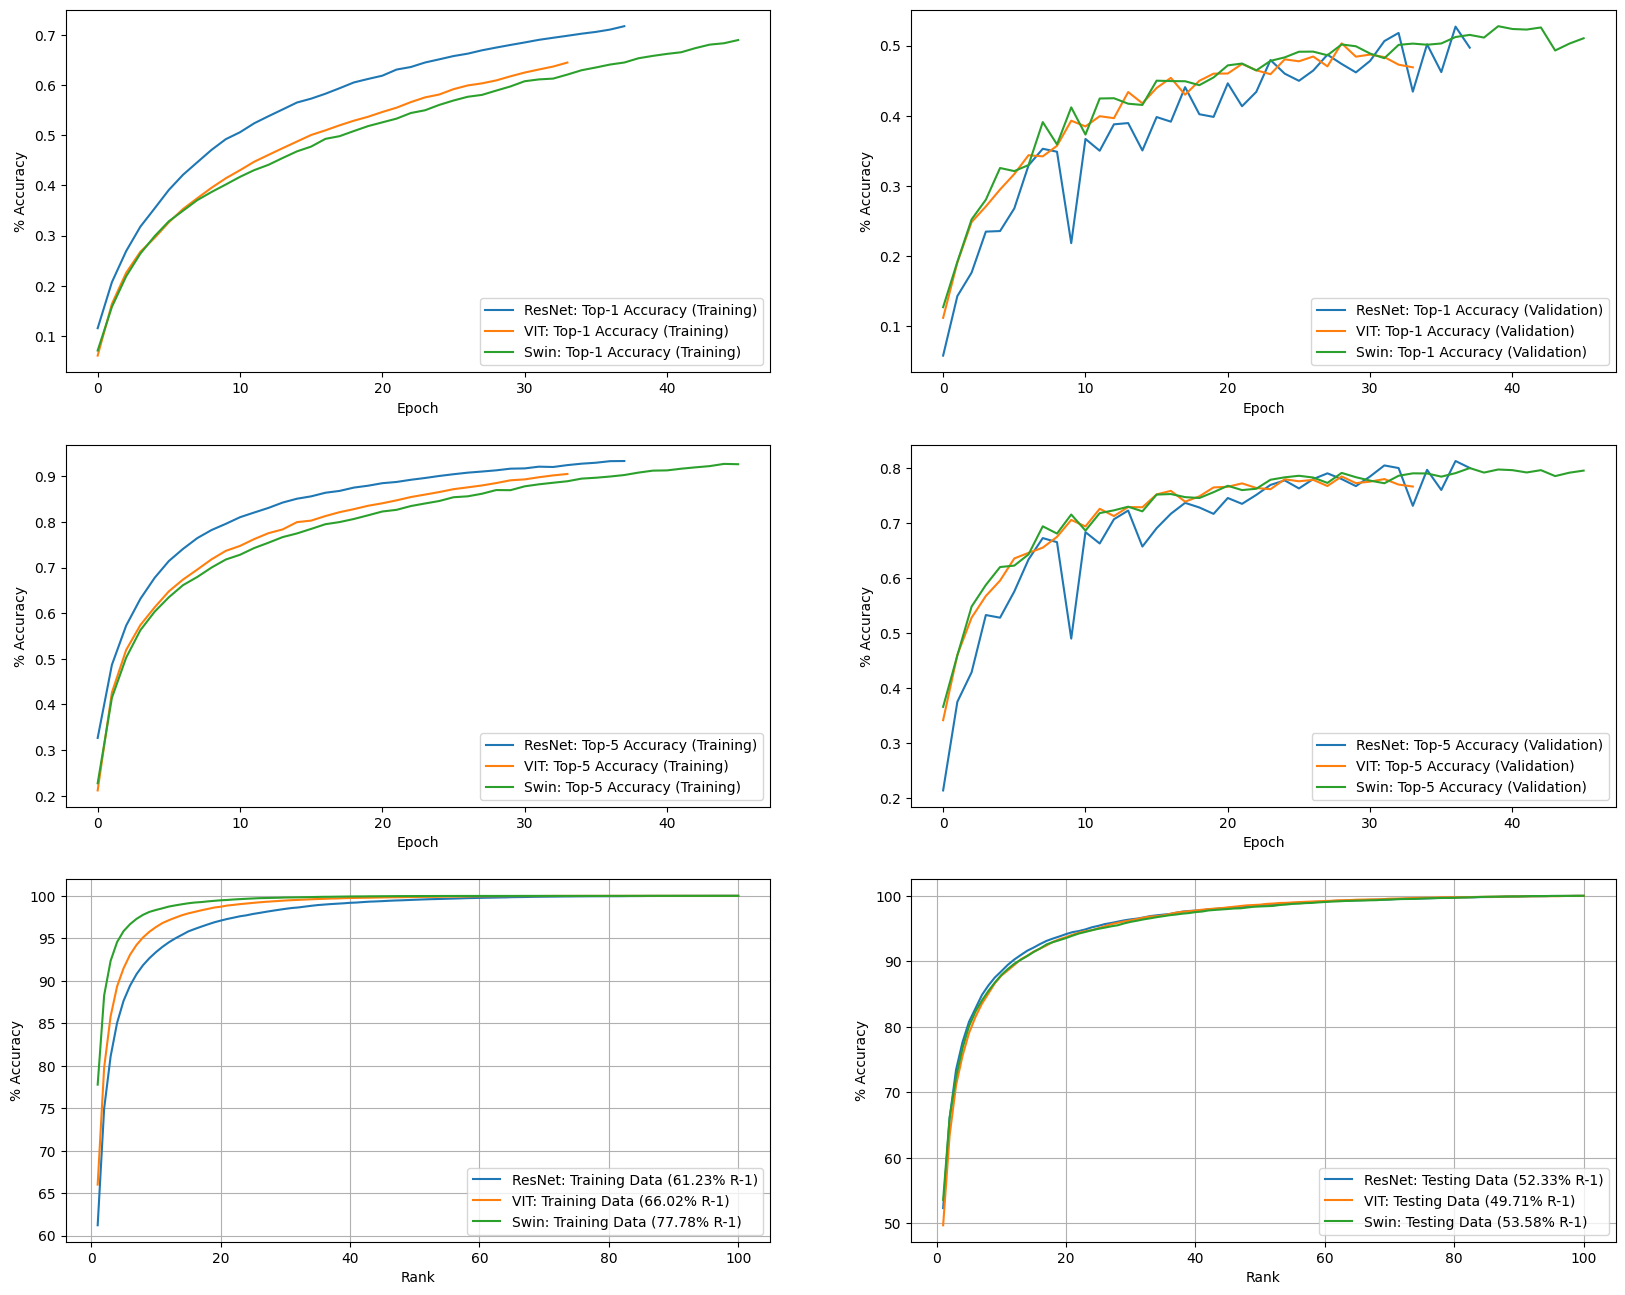

In [14]:
eval_models([history_resnet, history_vit, history_swin], [model_resnet, model_vit, model_swin], ['ResNet', 'VIT', 'Swin'])

Evaluation wise, we have some other perhaps surprising results, with ResNet beating the VIT, though Swin Transformer is out in front. That said, it's not a huge win for the swin transformer. We also see smoother training of the transformer, with a far less jagged looking validation accuracy plot.

As per the number of epochs these things run for noted above, there is some variation here from one training run to the next, but generally you'll see these three networks fininshing fairly close. If networks were trained for longer with more carefully selected learning rates (possibly a learning rate schedule) and we had a longer time-out on our early stopping, we'd see the transformers come out on top - though the gap would not be huge. Here, all networks are limited by their size. We could go bigger here for all of them, and that would likely see the transformers pull further ahead.

## Final Thoughts

So why don't transformers absolutely crush ResNet here? First up, we've actually got a lot of capacity in our ResNet - there are 9 convolution layers there, as opposed to two transformer layers in the VIT (plus the two convolution layers in the convolution head), so the CNN has a fair shot here. Second, CNNs give us a really good inductive bias for image classification tasks. Transformers can learn these relationships too, but it takes time (a lot of time). That said, if you run this 100 times, on average the VIT will win.

Looking at the VIT and the Swin Transformer, the result here is possibly a little misleading too. Swin Transformer is clearly out in front, but don't expect to see this every time. Our Swin Transformer does have more transformer layers, but each of those is less powerful than our regular old VIT. Alternate attention mechanisms like the shifted window attention used by Swin aren't trying to out perform full self-attention, they're just trying to do something as good more efficiently. Here, the random number generator gives a win for the Swin Transformer, but often these are going to perform pretty simiarly.

So does this mean that transformers aren't worth it? No. They do offer better performance here (in most runs) and surprising they're both faster to train than ResNet here. But transformers can be a bit harder to train, and you will see more variation with learning rates and other optimiser settings. Also, they do typically take longer to converge, and  benefit greatly from pre-training which we haven't done here - though we've seen elsewhere that this can give a nice bump in performance. However, keep in mind that CNNs were already pretty good at tasks such as the one we're condidering here, we can't expect things to suddenly take off like magic.

Ultimatley, CNN based models are still widely used in a lot of settings. They are (usually) more efficient than transformers, and can be easier to train. There are also a lot of really good pre-trained models out there to adapt. If you have enough time and data, you will probably get better performance out of a transformer, but if you dont', CNNs are still a good option.